<a href="https://colab.research.google.com/github/leticia1804/Trabalho-integrado-do-dado-ao-insigth/blob/main/let%C3%ADcia_projeto_integrado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Análise Comparativa das Temperaturas entre as Estações Meteorológicas
# Forte de Copacabana × Vila Militar

# Pós-Graduação em Ciência de Dados

# **Disciplina:** Big Data, Computação em Nuvem e Análise Computacional

# **Autora:** Letícia dos Santos

# **Fonte dos dados:** Instituto Nacional de Meteorologia (INMET)

# **Ano:** 2025

# CARREGAMENTO DO ARQUIVOS CSV DA BASE DE DADOS PELO USUÁRIO
# utilizando a biblioteca google.colab.files
from google.colab import files


# IMPORTAÇÃO DAS BIBLIOTECAS NECESSÁRIAS
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

#LEITURA DOS ARQUIVOS
copacabana = pd.read_csv(
    "dados_A652_H_2025-01-01_2025-12-31.csv",
     sep=';',
     encoding='latin1',
     skiprows=10) # Ignora as 10 primeiras linhas de metadados


vilamilitar = pd.read_csv(
    "dados_A621_H_2025-01-01_2025-12-31.csv",
     sep=';',
     encoding='latin1',
     skiprows=10) # Ignora as 10 primeiras linhas de metadados

Você pode inspecionar as primeiras linhas do arquivo CSV usando `open()` e `readline()` para ver o conteúdo bruto e identificar o delimitador correto.

In [ ]:

# inspecionar as primeiras linhas do arquivo CSV usando open() e readline()
#ver o conteúdo bruto e identificar o delimitador correto.

print('Primeiras 5 linhas de dados_A652_H_2025-01-01_2025-12-31.csv:')
with open('dados_A652_H_2025-01-01_2025-12-31.csv', 'r', encoding='utf-8') as f:
    for i in range(5):
        print(f.readline(), end='')

print('\nPrimeiras 5 linhas de dados_A621_H_2025-01-01_2025-12-31.csv:')
with open('dados_A621_H_2025-01-01_2025-12-31.csv', 'r', encoding='utf-8') as f:
    for i in range(5):
        print(f.readline(), end='')

Primeiras 5 linhas de dados_A652_H_2025-01-01_2025-12-31.csv:
Nome: RIO DE JANEIRO - FORTE DE COPACABANA
Codigo Estacao: A652
Latitude: -22.98833333
Longitude: -43.19055555
Altitude: 25.59

Primeiras 5 linhas de dados_A621_H_2025-01-01_2025-12-31.csv:
Nome: RIO DE JANEIRO - VILA MILITAR
Codigo Estacao: A621
Latitude: -22.86138888
Longitude: -43.41138888
Altitude: 30.43


In [ ]:
# RESUMO DAS PRINCIPAIS INFORMAÇÕES
copacabana.info()

vilamilitar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 9 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Data Medicao                                  8760 non-null   object 
 1   Hora Medicao                                  8760 non-null   int64  
 2   PRECIPITACAO TOTAL, HORARIO(mm)               8564 non-null   float64
 3   TEMPERATURA DO AR - BULBO SECO, HORARIA(Â°C)  8564 non-null   float64
 4   TEMPERATURA MAXIMA NA HORA ANT. (AUT)(Â°C)    8555 non-null   float64
 5   TEMPERATURA MINIMA NA HORA ANT. (AUT)(Â°C)    8554 non-null   float64
 6   UMIDADE RELATIVA DO AR, HORARIA(%)            4564 non-null   float64
 7   VENTO, VELOCIDADE HORARIA(m/s)                8563 non-null   float64
 8   Unnamed: 8                                    0 non-null      float64
dtypes: float64(7), int64(1), object(1)
memory usage: 616.1+ KB
<clas

In [ ]:
#print("Copacabana:", copacabana.shape)

#print("Vila Militar:", vilamilitar.shape)

# estatísticas descritivas para cada coluna numérica

copacabana.describe()


,Hora Medicao,"PRECIPITACAO TOTAL, HORARIO(mm)","TEMPERATURA DO AR - BULBO SECO, HORARIA(Â°C)",TEMPERATURA MAXIMA NA HORA ANT. (AUT)(Â°C),TEMPERATURA MINIMA NA HORA ANT. (AUT)(Â°C),"UMIDADE RELATIVA DO AR, HORARIA(%)","VENTO, VELOCIDADE HORARIA(m/s)",Unnamed: 8
count,8760.000000,8564.000000,8564.000000,8555.000000,8554.000000,4564.000000,8563.000000,0.0
mean,1150.000000,0.085147,23.269710,23.807189,22.767723,74.928571,2.236156,NaN
std,692.258169,0.765982,2.908405,3.127825,2.682753,12.292964,1.583623,NaN
min,0.000000,0.000000,15.600000,15.800000,15.300000,25.000000,0.200000,NaN
25%,575.000000,0.000000,21.200000,21.500000,20.900000,67.000000,1.100000,NaN
50%,1150.000000,0.000000,22.900000,23.500000,22.500000,76.000000,1.800000,NaN
75%,1725.000000,0.000000,25.000000,25.600000,24.500000,83.000000,2.800000,NaN
max,2300.000000,26.000000,38.400000,38.700000,36.800000,96.000000,11.600000,NaN


In [ ]:
vilamilitar.describe()

,Hora Medicao,"PRECIPITACAO TOTAL, HORARIO(mm)","TEMPERATURA DO AR - BULBO SECO, HORARIA(Â°C)",TEMPERATURA MAXIMA NA HORA ANT. (AUT)(Â°C),TEMPERATURA MINIMA NA HORA ANT. (AUT)(Â°C),"UMIDADE RELATIVA DO AR, HORARIA(%)","VENTO, VELOCIDADE HORARIA(m/s)",Unnamed: 8
count,8760.000000,8759.000000,8759.000000,8758.000000,8758.000000,8759.000000,8759.000000,0.0
mean,1150.000000,0.095559,23.946672,24.617024,23.318338,75.157438,1.137516,NaN
std,692.258169,0.918177,5.123218,5.254491,4.989753,17.428803,1.149815,NaN
min,0.000000,0.000000,10.700000,10.900000,10.000000,19.000000,0.000000,NaN
25%,575.000000,0.000000,20.500000,21.000000,20.000000,62.000000,0.000000,NaN
50%,1150.000000,0.000000,23.700000,24.300000,23.100000,78.000000,0.900000,NaN
75%,1725.000000,0.000000,27.100000,27.900000,26.400000,91.000000,1.900000,NaN
max,2300.000000,31.600000,40.900000,41.200000,40.300000,98.000000,8.000000,NaN


In [ ]:
#VERIFICANDO OS NOMES DAS COLUNAS
copacabana.columns


Index(['Data Medicao', 'Hora Medicao', 'PRECIPITACAO TOTAL, HORARIO(mm)',
       'TEMPERATURA DO AR - BULBO SECO, HORARIA(Â°C)',
       'TEMPERATURA MAXIMA NA HORA ANT. (AUT)(Â°C)',
       'TEMPERATURA MINIMA NA HORA ANT. (AUT)(Â°C)',
       'UMIDADE RELATIVA DO AR, HORARIA(%)', 'VENTO, VELOCIDADE HORARIA(m/s)',
       'Unnamed: 8'],
      dtype='object')

In [ ]:
vilamilitar.columns

Index(['Data Medicao', 'Hora Medicao', 'PRECIPITACAO TOTAL, HORARIO(mm)',
       'TEMPERATURA DO AR - BULBO SECO, HORARIA(Â°C)',
       'TEMPERATURA MAXIMA NA HORA ANT. (AUT)(Â°C)',
       'TEMPERATURA MINIMA NA HORA ANT. (AUT)(Â°C)',
       'UMIDADE RELATIVA DO AR, HORARIA(%)', 'VENTO, VELOCIDADE HORARIA(m/s)',
       'Unnamed: 8'],
      dtype='object')

In [ ]:
# TRATAMENTO E PADRONIZANDO OS DADOS DO INMET
# Renomeando os nomes das tabelas para facil entendimento

novo_nome = {

'Data Medicao':'Data',

'Hora Medicao':'Hora',

'PRECIPITACAO TOTAL, HORARIO(mm)':'Precipitacao',

'TEMPERATURA DO AR - BULBO SECO, HORARIA(Â°C)':'Temperatura',

'TEMPERATURA MAXIMA NA HORA ANT. (AUT)(Â°C)':'Temp_Max',

'TEMPERATURA MINIMA NA HORA ANT. (AUT)(Â°C)':'Temp_Min',

'UMIDADE RELATIVA DO AR, HORARIA(%)':'Umidade',

'VENTO, VELOCIDADE HORARIA(m/s)':'Vento'

}
copacabana.rename(columns=novo_nome,inplace=True)
vilamilitar.rename(columns=novo_nome,inplace=True)

# CONFERINDO NOVOS NOMES
copacabana.columns
vilamilitar.columns

Index(['Data', 'Hora', 'Precipitacao', 'Temperatura', 'Temp_Max', 'Temp_Min',
       'Umidade', 'Vento', 'Unnamed: 8'],
      dtype='object')

In [ ]:
#CRIANDO A COLUNA CIDADE
copacabana["Cidade"]="Forte de Copacabana"
vilamilitar["Cidade"]="Vila Militar"

#CONFERINDO
copacabana.head()


,Data,Hora,Precipitacao,Temperatura,Temp_Max,Temp_Min,Umidade,Vento,Unnamed: 8,Cidade
0,2025-01-01,0,0.0,24.2,24.3,24.0,NaN,1.9,NaN,Forte de Copacabana
1,2025-01-01,100,0.0,24.0,24.2,23.9,NaN,1.6,NaN,Forte de Copacabana
2,2025-01-01,200,0.0,23.8,24.0,23.7,NaN,1.8,NaN,Forte de Copacabana
3,2025-01-01,300,0.0,23.5,23.8,23.5,NaN,1.1,NaN,Forte de Copacabana
4,2025-01-01,400,0.0,23.5,23.6,23.4,NaN,0.2,NaN,Forte de Copacabana


In [ ]:
#TRANSFORMANDO O FORMATO DA COLUNA DATA
copacabana["Data"] = pd.to_datetime(
    copacabana["Data"],
    format="%Y-%m-%d" # Alterado para corresponder ao formato real da data
)

vilamilitar["Data"] = pd.to_datetime(
    vilamilitar["Data"],
    format="%Y-%m-%d" # Alterado para corresponder ao formato real da data
)

#CONFERINDO
copacabana.info()
vilamilitar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Data          8760 non-null   datetime64[ns]
 1   Hora          8760 non-null   int64         
 2   Precipitacao  8564 non-null   float64       
 3   Temperatura   8564 non-null   float64       
 4   Temp_Max      8555 non-null   float64       
 5   Temp_Min      8554 non-null   float64       
 6   Umidade       4564 non-null   float64       
 7   Vento         8563 non-null   float64       
 8   Unnamed: 8    0 non-null      float64       
 9   Cidade        8760 non-null   object        
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 684.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0 

In [ ]:
#TRANSFORMANDO A HORA
copacabana["Hora"] = (
    copacabana["Hora"]
    .astype(str)
    .str.zfill(4)
)

vilamilitar["Hora"] = (
    vilamilitar["Hora"]
    .astype(str)
    .str.zfill(4)
)

copacabana.head()

,Data,Hora,Precipitacao,Temperatura,Temp_Max,Temp_Min,Umidade,Vento,Unnamed: 8,Cidade
0,2025-01-01,0000,0.0,24.2,24.3,24.0,NaN,1.9,NaN,Forte de Copacabana
1,2025-01-01,0100,0.0,24.0,24.2,23.9,NaN,1.6,NaN,Forte de Copacabana
2,2025-01-01,0200,0.0,23.8,24.0,23.7,NaN,1.8,NaN,Forte de Copacabana
3,2025-01-01,0300,0.0,23.5,23.8,23.5,NaN,1.1,NaN,Forte de Copacabana
4,2025-01-01,0400,0.0,23.5,23.6,23.4,NaN,0.2,NaN,Forte de Copacabana


In [ ]:
#CRIANDO DATA+HORA
copacabana["DataHora"] = pd.to_datetime(

    copacabana["Data"].dt.strftime("%Y-%m-%d") +

    " " +

    copacabana["Hora"].str[:2] +

    ":" +

    copacabana["Hora"].str[2:]

)

vilamilitar["DataHora"] = pd.to_datetime(

    vilamilitar["Data"].dt.strftime("%Y-%m-%d") +

    " " +

    vilamilitar["Hora"].str[:2] +

    ":" +

    vilamilitar["Hora"].str[2:]

)

copacabana[["Data","Hora","DataHora"]].head()
vilamilitar[["Data","Hora","DataHora"]].head()

,Data,Hora,DataHora
0,2025-01-01,0000,2025-01-01 00:00:00
1,2025-01-01,0100,2025-01-01 01:00:00
2,2025-01-01,0200,2025-01-01 02:00:00
3,2025-01-01,0300,2025-01-01 03:00:00
4,2025-01-01,0400,2025-01-01 04:00:00


In [ ]:
#Nesta etapa são criadas novas variáveis derivadas da coluna DataHora.

#Essas variáveis facilitarão as análises temporais, permitindo estudar o comportamento das temperaturas ao longo dos meses, trimestres e estações do ano.

#A criação dessas colunas também simplifica a modelagem dimensional no Power BI.

copacabana["Ano"] = copacabana["DataHora"].dt.year
vilamilitar["Ano"] = vilamilitar["DataHora"].dt.year

copacabana["MesNumero"] = copacabana["DataHora"].dt.month
vilamilitar["MesNumero"] = vilamilitar["DataHora"].dt.month

#NOMEANDO OS MESES PARA ANALISE POWER BI
meses = {

1:"Janeiro",

2:"Fevereiro",

3:"Março",

4:"Abril",

5:"Maio",

6:"Junho",

7:"Julho",

8:"Agosto",

9:"Setembro",

10:"Outubro",

11:"Novembro",

12:"Dezembro"

}

copacabana["Mes"] = copacabana["MesNumero"].map(meses)
vilamilitar["Mes"] = vilamilitar["MesNumero"].map(meses)

copacabana["Dia"] = copacabana["DataHora"].dt.day
vilamilitar["Dia"] = vilamilitar["DataHora"].dt.day

copacabana["Hora_Numero"] = copacabana["DataHora"].dt.hour
vilamilitar["Hora_Numero"] = vilamilitar["DataHora"].dt.hour

def estacao(mes):

    if mes in [12,1,2]:
        return "Verão"

    elif mes in [3,4,5]:
        return "Outono"

    elif mes in [6,7,8]:
        return "Inverno"

    else:
        return "Primavera"

copacabana["Estacao"] = copacabana["MesNumero"].apply(estacao)
vilamilitar["Estacao"] = vilamilitar["MesNumero"].apply(estacao)

#CONFERINDO
copacabana.head()
vilamilitar.head()

,Data,Hora,Precipitacao,Temperatura,Temp_Max,Temp_Min,Umidade,Vento,Unnamed: 8,Cidade,DataHora,Ano,MesNumero,Mes,Dia,Hora_Numero,Estacao
0,2025-01-01,0000,0.0,24.4,25.5,24.4,80.0,0.2,NaN,Vila Militar,2025-01-01 00:00:00,2025,1,Janeiro,1,0,Verão
1,2025-01-01,0100,0.0,23.6,24.4,23.2,89.0,0.0,NaN,Vila Militar,2025-01-01 01:00:00,2025,1,Janeiro,1,1,Verão
2,2025-01-01,0200,0.0,24.3,24.4,23.6,85.0,0.0,NaN,Vila Militar,2025-01-01 02:00:00,2025,1,Janeiro,1,2,Verão
3,2025-01-01,0300,0.0,23.8,24.4,23.7,89.0,0.1,NaN,Vila Militar,2025-01-01 03:00:00,2025,1,Janeiro,1,3,Verão
4,2025-01-01,0400,0.0,24.6,24.6,23.8,78.0,0.4,NaN,Vila Militar,2025-01-01 04:00:00,2025,1,Janeiro,1,4,Verão


In [ ]:
# Análise Exploratória dos Dados (EDA)

#Após o tratamento e padronização dos dados, realizou-se uma Análise Exploratória dos Dados (Exploratory Data Analysis – EDA).

#O objetivo desta etapa é compreender o comportamento das variáveis meteorológicas, identificar padrões, detectar possíveis inconsistências e comparar as características climáticas entre as estações Forte de Copacabana e Vila Militar.

#Essa análise servirá de base para a construção do dashboard no Power BI e para a interpretação dos resultados obtidos.

#VERIFICANDO VALORES AUSENTES

print("COPACABANA")

display(copacabana.isnull().sum())

print("\nVILA MILITAR")

display(vilamilitar.isnull().sum())

COPACABANA


,0
Data,0
Hora,0
Precipitacao,196
Temperatura,196
Temp_Max,205
Temp_Min,206
Umidade,4196
Vento,197
Unnamed: 8,8760
Cidade,0



VILA MILITAR


,0
Data,0
Hora,0
Precipitacao,1
Temperatura,1
Temp_Max,2
Temp_Min,2
Umidade,1
Vento,1
Unnamed: 8,8760
Cidade,0


In [ ]:
#visualizar em porcentagem

faltantes_copa = (copacabana.isnull().mean()*100).round(2)

faltantes_vm = (vilamilitar.isnull().mean()*100).round(2)

print(faltantes_copa)

print(faltantes_vm)

Data              0.00
Hora              0.00
Precipitacao      2.24
Temperatura       2.24
Temp_Max          2.34
Temp_Min          2.35
Umidade          47.90
Vento             2.25
Unnamed: 8      100.00
Cidade            0.00
DataHora          0.00
Ano               0.00
MesNumero         0.00
Mes               0.00
Dia               0.00
Hora_Numero       0.00
Estacao           0.00
dtype: float64
Data              0.00
Hora              0.00
Precipitacao      0.01
Temperatura       0.01
Temp_Max          0.02
Temp_Min          0.02
Umidade           0.01
Vento             0.01
Unnamed: 8      100.00
Cidade            0.00
DataHora          0.00
Ano               0.00
MesNumero         0.00
Mes               0.00
Dia               0.00
Hora_Numero       0.00
Estacao           0.00
dtype: float64


In [ ]:
copacabana.describe().T
vilamilitar.describe().T


,count,mean,min,25%,50%,75%,max,std
Data,8760,2025-07-02 00:00:00,2025-01-01 00:00:00,2025-04-02 00:00:00,2025-07-02 00:00:00,2025-10-01 00:00:00,2025-12-31 00:00:00,NaN
Precipitacao,8759.0,0.095559,0.0,0.0,0.0,0.0,31.6,0.918177
Temperatura,8759.0,23.946672,10.7,20.5,23.7,27.1,40.9,5.123218
Temp_Max,8758.0,24.617024,10.9,21.0,24.3,27.9,41.2,5.254491
Temp_Min,8758.0,23.318338,10.0,20.0,23.1,26.4,40.3,4.989753
Umidade,8759.0,75.157438,19.0,62.0,78.0,91.0,98.0,17.428803
Vento,8759.0,1.137516,0.0,0.0,0.9,1.9,8.0,1.149815
Unnamed: 8,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DataHora,8760,2025-07-02 11:30:00,2025-01-01 00:00:00,2025-04-02 05:45:00,2025-07-02 11:30:00,2025-10-01 17:15:00,2025-12-31 23:00:00,NaN
Ano,8760.0,2025.0,2025.0,2025.0,2025.0,2025.0,2025.0,0.0


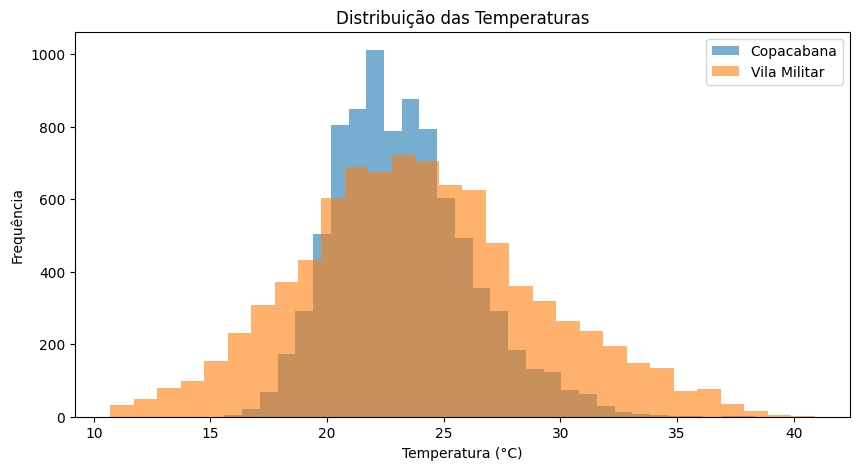

In [ ]:
#DISTRIBUIÇÃO DAS TEMPERATURAS

plt.figure(figsize=(10,5))

plt.hist(
    copacabana["Temperatura"],
    bins=30,
    alpha=0.6,
    label="Copacabana"
)

plt.hist(
    vilamilitar["Temperatura"],
    bins=30,
    alpha=0.6,
    label="Vila Militar"
)

plt.xlabel("Temperatura (°C)")

plt.ylabel("Frequência")

plt.title("Distribuição das Temperaturas")

plt.legend()

plt.show()

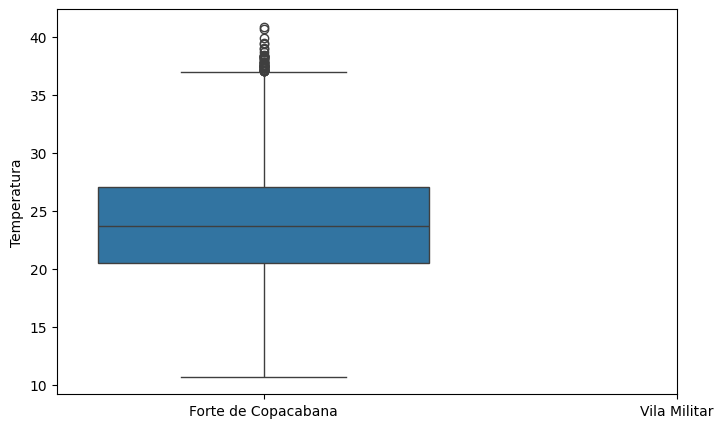

In [ ]:
#VERIFICANDO OUTLIERS
plt.figure(figsize=(8,5))

sns.boxplot(
    data=[

        copacabana["Temperatura"],

        vilamilitar["Temperatura"]

    ]

)

plt.xticks(

    [0,1],

    ["Forte de Copacabana","Vila Militar"]

)

plt.ylabel("Temperatura")

plt.show()

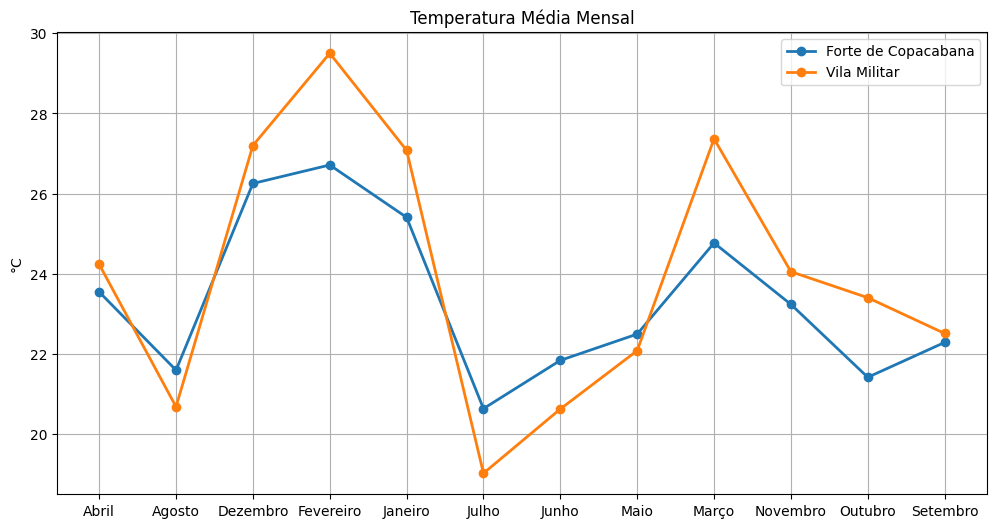

In [ ]:
#EVOLUÇÃO DA TEMPERATURA MEDIA MENSAL
media_copa = copacabana.groupby("Mes")["Temperatura"].mean()

media_vm = vilamilitar.groupby("Mes")["Temperatura"].mean()

plt.figure(figsize=(12,6))

plt.plot(
    media_copa,
    marker='o',
    linewidth=2,
    label="Forte de Copacabana"
)

plt.plot(
    media_vm,
    marker='o',
    linewidth=2,
    label="Vila Militar"
)

plt.legend()

plt.grid()

plt.title("Temperatura Média Mensal")

plt.ylabel("°C")

plt.show()

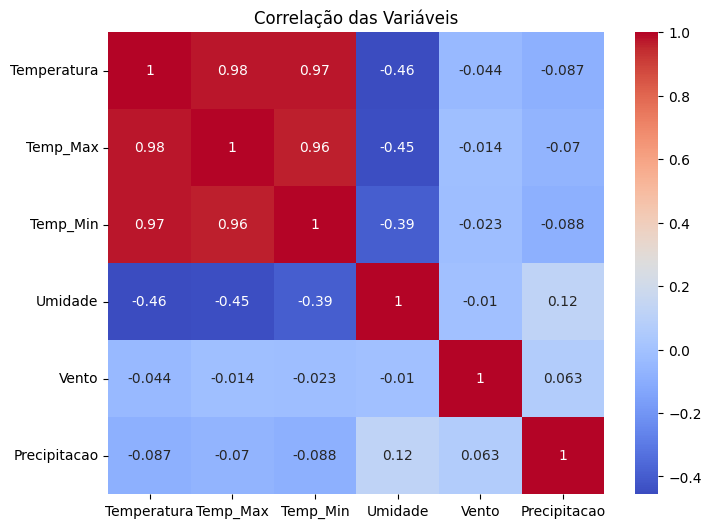

In [ ]:
#CORRELAÇÃO ENTRE AS VARIÁVEIS
corr = copacabana[

["Temperatura",

"Temp_Max",

"Temp_Min",

"Umidade",

"Vento",

"Precipitacao"]

].corr()

plt.figure(figsize=(8,6))

sns.heatmap(

corr,

annot=True,

cmap="coolwarm"

)

plt.title("Correlação das Variáveis")

plt.show()

In [ ]:
#BASE FINAL PARA ANALISE NO POWER BI

Base_Final_INMET = pd.concat(

    [

        copacabana,

        vilamilitar

    ],

    ignore_index=True

)

#AMPLITUDE TERMICA

Base_Final_INMET["Amplitude"] = (
    Base_Final_INMET["Temp_Max"] -
    Base_Final_INMET["Temp_Min"]
)

#PERIODO DO DIA

def periodo(hora):

    if 0 <= hora < 6:
        return "Madrugada"

    elif hora < 12:
        return "Manhã"

    elif hora < 18:
        return "Tarde"

    else:
        return "Noite"

Base_Final_INMET["Periodo"] = (
    Base_Final_INMET["Hora_Numero"]
    .apply(periodo)
)

Base_Final_INMET.head()
Base_Final_INMET.shape


#EXPORTANDO BASE FINAL E TRANSFORMANDO DECIMALDE '.' PARA ','
Base_Final_INMET.to_csv(
    "Base_Final_INMET.csv",
    index=False,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)